# Try Flow on Gene Embeddings.

## Prepare Notebook.

### Import the Libraries.

In [24]:
from typing import Literal

import anndata as ad
import numpy as np
import pandas as pd
import scanpy as sc
from scipy import sparse
import seaborn as sns

### Define Utility Function.

In [2]:
def gene_emb_ols(
    adata: ad.AnnData,
    M: np.ndarray,
    proj_type: Literal["identity", "mahalanobis"] = "identity",
    l2_reg: float = 0.0,
    eps: float = 1e-12,
    layers_key: str | None = None,
    key_added: str = "gene_ols",
    reconstruct: bool = False,
) -> ad.AnnData:
    """Project gene expression using pre‑computed gene embeddings.

    Stores forward projector P and exact inverse Q in adata.uns.
    """
    X = adata.X if layers_key is None else adata.layers[layers_key]

    _, Gx = X.shape
    Gm, D = M.shape
    if Gx != Gm:
        raise ValueError(f"Gene mismatch: X has {Gx} genes, M has {Gm}.")

    K = M.T @ M  # D x D
    I_D = np.eye(D)

    if proj_type == "identity":
        A = K + l2_reg * I_D
        P = M @ np.linalg.inv(A)
        # Q = A K^{-1} M^T   (exact left inverse: Q P = I)
        # Use pseudo‑inverse of K if needed
        K_inv = np.linalg.inv(K + eps * I_D)  # small ridge for safety
        Q = A @ K_inv @ M.T

    elif proj_type == "mahalanobis":
        if l2_reg == 0.0:
            # P = M K^{-1}
            K_inv = np.linalg.inv(K + eps * I_D)
            P = M @ K_inv
            Q = M.T  # because M^T P = K K^{-1} = I
        else:
            # P = M ((1+l2_reg) K + l2_reg*eps I)^{-1}
            A = (1 + l2_reg) * K + l2_reg * eps * I_D
            P = M @ np.linalg.inv(A)
            # Q = A K^{-1} M^T
            K_inv = np.linalg.inv(K + eps * I_D)
            Q = A @ K_inv @ M.T
    else:
        raise ValueError("proj_type must be 'identity' or 'mahalanobis'")

    # Apply to all cells
    Y = X @ P

    # Store result and parameters
    if reconstruct:
        X_recon = Y @ Q
        adata.layers[f"X_recon_{key_added}"] = X_recon
    adata.obsm[f"X_{key_added}"] = np.asarray(Y) if sparse.issparse(Y) else Y
    adata.uns[key_added + "_params"] = {
        "proj_type": proj_type,
        "l2_reg": l2_reg,
        "eps": eps,
        "P": P,  # G × D forward projector
        "Q": Q,  # D × G exact inverse projector
    }
    return adata

## Data.

### Read Data.

In [3]:
data_path = "/Users/lorenzo.consoli/Downloads/data/combosciplex.h5ad"

# create dataset
adata = ad.read_h5ad(data_path)
adata

AnnData object with n_obs × n_vars = 63378 × 27518
    obs: 'sample', 'Size_Factor', 'n.umi', 'RT_well', 'Drug1', 'Drug2', 'Well', 'n_genes', 'n_genes_by_counts', 'total_counts', 'total_counts_mt', 'pct_counts_mt', 'leiden', 'condition', 'pathway1', 'pathway2', 'split', 'control', 'cell_type'
    var: 'id', 'n_cells', 'mt', 'n_cells_by_counts', 'mean_counts', 'pct_dropout_by_counts', 'total_counts', 'highly_variable', 'means', 'dispersions', 'dispersions_norm'
    uns: 'Drug1_colors', 'Drug2_colors', 'Well_colors', 'condition_colors', 'dendrogram_leiden', 'hvg', 'leiden', 'leiden_colors', 'neighbors', 'pathway1_colors', 'pathway2_colors', 'pathway_colors', 'pca', 'rank_genes_groups', 'split_colors', 'umap'
    obsm: 'X_pca', 'X_umap'
    varm: 'PCs'
    layers: 'counts'
    obsp: 'connectivities', 'distances'

### Select HVGs.

In [4]:
adata_hvgs = adata.copy()[:, adata.var.highly_variable]
adata_hvgs

View of AnnData object with n_obs × n_vars = 63378 × 5000
    obs: 'sample', 'Size_Factor', 'n.umi', 'RT_well', 'Drug1', 'Drug2', 'Well', 'n_genes', 'n_genes_by_counts', 'total_counts', 'total_counts_mt', 'pct_counts_mt', 'leiden', 'condition', 'pathway1', 'pathway2', 'split', 'control', 'cell_type'
    var: 'id', 'n_cells', 'mt', 'n_cells_by_counts', 'mean_counts', 'pct_dropout_by_counts', 'total_counts', 'highly_variable', 'means', 'dispersions', 'dispersions_norm'
    uns: 'Drug1_colors', 'Drug2_colors', 'Well_colors', 'condition_colors', 'dendrogram_leiden', 'hvg', 'leiden', 'leiden_colors', 'neighbors', 'pathway1_colors', 'pathway2_colors', 'pathway_colors', 'pca', 'rank_genes_groups', 'split_colors', 'umap'
    obsm: 'X_pca', 'X_umap'
    varm: 'PCs'
    layers: 'counts'
    obsp: 'connectivities', 'distances'

### Scaling adata.

In [5]:
sc.pp.scale(adata_hvgs)
adata_hvgs

/Users/lorenzo.consoli/micromamba/envs/scflow12/lib/python3.12/functools.py:912: UserWarning: Received a view of an AnnData. Making a copy.
  return dispatch(args[0].__class__)(*args, **kw)
/Users/lorenzo.consoli/micromamba/envs/scflow12/lib/python3.12/functools.py:912: UserWarning: zero-centering a sparse array/matrix densifies it.
  return dispatch(args[0].__class__)(*args, **kw)


AnnData object with n_obs × n_vars = 63378 × 5000
    obs: 'sample', 'Size_Factor', 'n.umi', 'RT_well', 'Drug1', 'Drug2', 'Well', 'n_genes', 'n_genes_by_counts', 'total_counts', 'total_counts_mt', 'pct_counts_mt', 'leiden', 'condition', 'pathway1', 'pathway2', 'split', 'control', 'cell_type'
    var: 'id', 'n_cells', 'mt', 'n_cells_by_counts', 'mean_counts', 'pct_dropout_by_counts', 'total_counts', 'highly_variable', 'means', 'dispersions', 'dispersions_norm', 'mean', 'std'
    uns: 'Drug1_colors', 'Drug2_colors', 'Well_colors', 'condition_colors', 'dendrogram_leiden', 'hvg', 'leiden', 'leiden_colors', 'neighbors', 'pathway1_colors', 'pathway2_colors', 'pathway_colors', 'pca', 'rank_genes_groups', 'split_colors', 'umap'
    obsm: 'X_pca', 'X_umap'
    varm: 'PCs'
    layers: 'counts'
    obsp: 'connectivities', 'distances'

## Embedding with PCA.

### Get PCA Matrix.

In [6]:
# Compute PCA on the highly variable genes (you already have adata_hvgs)
D = 50
sc.tl.pca(adata_hvgs, n_comps=D, svd_solver="arpack")

### Embed Data.

In [7]:
# The PCA loadings are a (genes × D) matrix
M_pca = adata_hvgs.varm["PCs"]  # shape (n_genes, D)

# Now use your function
gene_emb_ols(adata_hvgs, M_pca, proj_type="identity", key_added="emb_ols_pca", reconstruct=True)

AnnData object with n_obs × n_vars = 63378 × 5000
    obs: 'sample', 'Size_Factor', 'n.umi', 'RT_well', 'Drug1', 'Drug2', 'Well', 'n_genes', 'n_genes_by_counts', 'total_counts', 'total_counts_mt', 'pct_counts_mt', 'leiden', 'condition', 'pathway1', 'pathway2', 'split', 'control', 'cell_type'
    var: 'id', 'n_cells', 'mt', 'n_cells_by_counts', 'mean_counts', 'pct_dropout_by_counts', 'total_counts', 'highly_variable', 'means', 'dispersions', 'dispersions_norm', 'mean', 'std'
    uns: 'Drug1_colors', 'Drug2_colors', 'Well_colors', 'condition_colors', 'dendrogram_leiden', 'hvg', 'leiden', 'leiden_colors', 'neighbors', 'pathway1_colors', 'pathway2_colors', 'pathway_colors', 'pca', 'rank_genes_groups', 'split_colors', 'umap', 'emb_ols_pca_params'
    obsm: 'X_pca', 'X_umap', 'X_emb_ols_pca'
    varm: 'PCs'
    layers: 'counts', 'X_recon_emb_ols_pca'
    obsp: 'connectivities', 'distances'

### Compute Neighbors and UMAP.

In [8]:
sc.pp.neighbors(adata_hvgs, use_rep="X_emb_ols_pca")
sc.tl.umap(adata_hvgs)

### Plot.

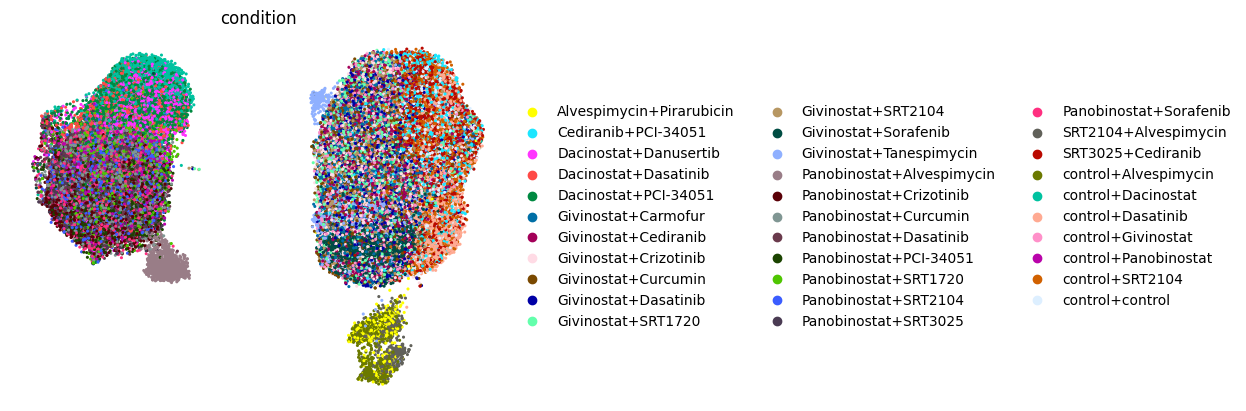

In [9]:
sc.pl.umap(
    adata_hvgs,
    color="condition",
    s=20,
    frameon=False,
)  # replace with your cell-type column

## Sanity checks.

### Check distribution of residuals per sample.

Should peak at 0 and decay pretty fast.

<Axes: ylabel='Count'>

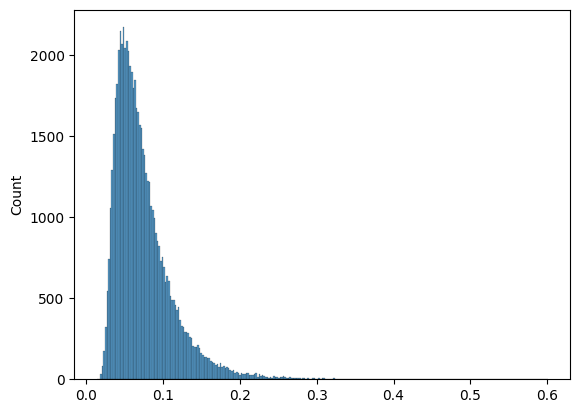

In [10]:
X_true = adata_hvgs.X
X_recon = adata_hvgs.layers["X_recon_emb_ols_pca"]
res = X_true - X_recon

X_true_mean = X_true.mean(0)
res_mean = res.mean(0)

n_cells = X_true.shape[0]
res_cov_per_cell = np.einsum("...d,...d->...", (X_true - X_true_mean), (res - res_mean)) / (n_cells - 1)
sns.histplot(res_cov_per_cell)

### Check covariance matrix of residuals.

Compute covariance matrix of residuals.

In [11]:
n_cells = X_true.shape[0]
res_cov = np.einsum("nm,nd->md", (X_true - X_true_mean), (res - res_mean)) / (n_cells - 1)

Compute covariance matrix of real data.

In [12]:
n_cells = X_true.shape[0]
true_cov = np.einsum("nm,nd->md", (X_true - X_true_mean), (X_true - X_true_mean)) / (n_cells - 1)

In [13]:
true_cov.shape

(5000, 5000)

In [14]:
res_cov.shape

(5000, 5000)

Compute trace of real covariance matrix.

In [16]:
trace_cross_true = np.trace(true_cov)
trace_cross_true

np.float64(4999.999999999985)

Compute trace of covariance of residuals.

In [17]:
trace_cross = np.trace(res_cov)
trace_cross

np.float64(4725.820374763256)

In [18]:
trace_cross / trace_cross_true

np.float64(0.945164074952654)

Plot heatmap true covariance.

<Axes: >

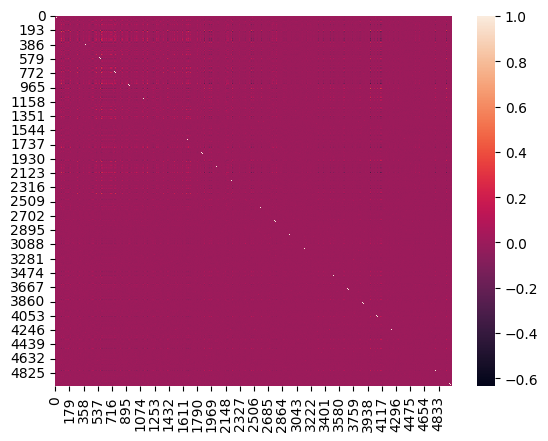

In [20]:
sns.heatmap(true_cov)

Plot heatmap residual covariance.

<Axes: >

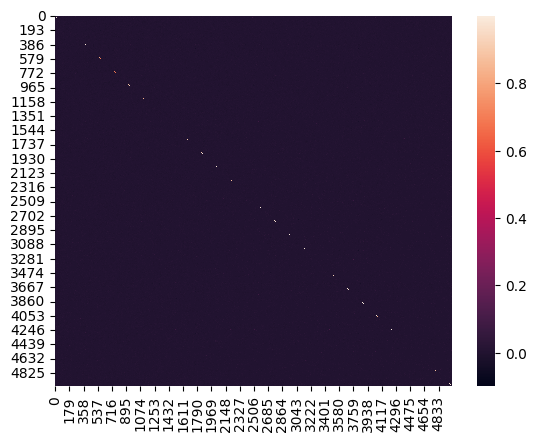

In [19]:
sns.heatmap(res_cov)

Compute norm.

In [ ]:
frob_cross = np.linalg.norm(res_cov, "fro")
frob_Xcov = np.linalg.norm(np.cov(X_true.T), "fro")
ratio = frob_cross / frob_Xcov
ratio

np.float64(0.5804206869314765)

## Pretrained Gene2Vec Embeddings.

### Read Embedding file.

In [25]:
emb_path = "~/Desktop/embeddings_d200.csv"
emb_df = pd.read_csv(emb_path)
emb_df

,gene_id,1,2,3,4,5,6,7,8,9,...,191,192,193,194,195,196,197,198,199,200
0,ENSG00000121410,0.099016,0.066245,-0.034797,-0.127031,-0.163268,0.298642,-0.020602,0.175843,0.222847,...,0.252068,0.145172,0.103029,0.338178,-0.127850,-0.113639,-0.070926,0.193559,-0.178107,-0.236483
1,ENSG00000268895,0.265411,0.352518,-0.137365,0.317857,-0.292131,0.006582,0.007641,0.347823,0.413142,...,-0.208437,0.230695,0.171515,-0.083703,-0.553166,-0.160137,-0.101731,-0.140372,-0.270881,-0.308397
2,ENSG00000148584,-0.023116,-0.278042,0.005570,-0.172919,-0.182847,0.105562,-0.259468,-0.152102,0.359117,...,0.116594,0.033837,0.173990,0.060071,-0.095825,-0.159587,0.071510,-0.061185,-0.386980,-0.295633
3,ENSG00000175899,0.339659,-0.035215,0.109926,-0.149196,-0.066475,-0.161970,0.274924,0.263427,0.734468,...,0.049068,0.147131,-0.049069,-0.287764,-0.536120,-0.336445,0.117614,0.054420,-0.033723,-0.211588
4,ENSG00000245105,0.201135,0.122087,0.100157,-0.092252,-0.136763,0.143286,0.215210,0.462383,0.463350,...,0.319601,0.780922,0.311619,-0.337479,0.157979,-0.052836,0.258976,0.190435,0.291907,-0.192425
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
19145,ENSG00000203995,-0.033953,0.094068,0.264330,-0.061232,0.333482,-0.312518,-0.464959,0.360981,-0.070702,...,0.222452,0.316357,-0.172928,-0.090469,0.044953,-0.213729,-0.160166,-0.415021,-0.003096,0.029933
19146,ENSG00000162378,-0.151100,0.236209,0.136979,0.123823,-0.004116,0.174072,0.014654,-0.027329,-0.167401,...,-0.276173,-0.299995,0.131436,-0.180700,-0.063652,0.188223,-0.114472,0.367000,-0.068562,-0.616409
19147,ENSG00000159840,0.053769,0.520952,-0.317258,0.012854,0.023016,-0.125229,-0.268413,0.015843,0.280043,...,-0.362270,0.080872,0.088854,0.225019,-0.235759,0.221158,0.288307,-0.540316,0.283822,-0.016495
19148,ENSG00000074755,-0.260770,-0.065605,0.223500,-0.079694,0.055594,-0.125973,0.355050,-0.026904,0.059839,...,-0.057414,-0.131816,0.191609,-0.130435,-0.264610,-0.149254,0.046535,0.041639,-0.227059,-0.159789


### Get embedding for HVGs.